# XGBoost Baseline Model
This notebook implements the XGBoost baseline for Fraud Prediction on the Indian Retail Dataset.

In [2]:
import pandas as pd
import numpy as np
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    from sklearn.ensemble import GradientBoostingClassifier
    print("WARNING: XGBoost not found. Using Sklearn GradientBoostingClassifier.")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Load Data

In [3]:
df = pd.read_csv("online_retail_indian_augmented.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Is_Return,Total_Price,City,State,Latitude,Longitude,Product_Return_Rate,User_Global_Return_Rate,StockCode_Base,Multi_Size_Order
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,0,83.4,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.210705,0.184411,85048.0,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.296208,0.184411,79323.0,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.332672,0.184411,79323.0,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,0,100.8,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.101050,0.184411,22041.0,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,0,30.0,Bhimavaram,Andhra Pradesh,16.5441,81.523,0.147180,0.184411,21232.0,True


## 2. Define Is_Fraud Target

In [4]:
conditions = (
    (df['Is_Return'] == 1) & 
    ((df['User_Global_Return_Rate'] > 0.7) | (df['Multi_Size_Order'] == True))
)
df['Is_Fraud'] = np.where(conditions, 1, 0)

print(f"Fraud Distrubution:\n{df['Is_Fraud'].value_counts()}")
print(f"Fraud Rate: {df['Is_Fraud'].mean()*100:.2f}%")

Fraud Distrubution:
Is_Fraud
0    766240
1     42308
Name: count, dtype: int64
Fraud Rate: 5.23%


## 3. Preparation for XGBoost

In [5]:
features = ['Total_Price', 'Product_Return_Rate', 'Latitude', 'Longitude', 'Quantity']

# Encode Categoricals
if 'State' in df.columns:
    df['State'] = df['State'].astype('category').cat.codes
    features.append('State')

# Date Features
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Hour'] = df['InvoiceDate'].dt.hour
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
features.extend(['Hour', 'Month', 'DayOfWeek'])

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Is_Return,Total_Price,City,...,Latitude,Longitude,Product_Return_Rate,User_Global_Return_Rate,StockCode_Base,Multi_Size_Order,Is_Fraud,Hour,Month,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,0,83.4,Bhimavaram,...,16.5441,81.523,0.210705,0.184411,85048.0,True,0,7,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,...,16.5441,81.523,0.296208,0.184411,79323.0,True,0,7,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,0,81.0,Bhimavaram,...,16.5441,81.523,0.332672,0.184411,79323.0,True,0,7,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,0,100.8,Bhimavaram,...,16.5441,81.523,0.101050,0.184411,22041.0,True,0,7,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,0,30.0,Bhimavaram,...,16.5441,81.523,0.147180,0.184411,21232.0,True,0,7,12,1


In [7]:
X = df[features]
y = df['Is_Fraud']

In [8]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 4. Train Model

In [9]:
print(f"Training Model on {X_train.shape[0]} samples...")

if HAS_XGB:
    model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1
    )
else:
    model = GradientBoostingClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        random_state=42
    )

model.fit(X_train, y_train)

Training Model on 646838 samples...


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,6
,min_impurity_decrease,0.0
,init,None


## 5. Evaluate

In [10]:
preds_prob = model.predict_proba(X_test)[:, 1]
preds_class = model.predict(X_test)

report = classification_report(y_test, preds_class)
print("\nClassification Report:")
print(report)

auc = roc_auc_score(y_test, preds_prob)
print(f"ROC AUC Score: {auc:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98    153248
           1       0.65      0.39      0.49      8462

    accuracy                           0.96    161710
   macro avg       0.81      0.69      0.73    161710
weighted avg       0.95      0.96      0.95    161710

ROC AUC Score: 0.9763


### Confusion Matrix

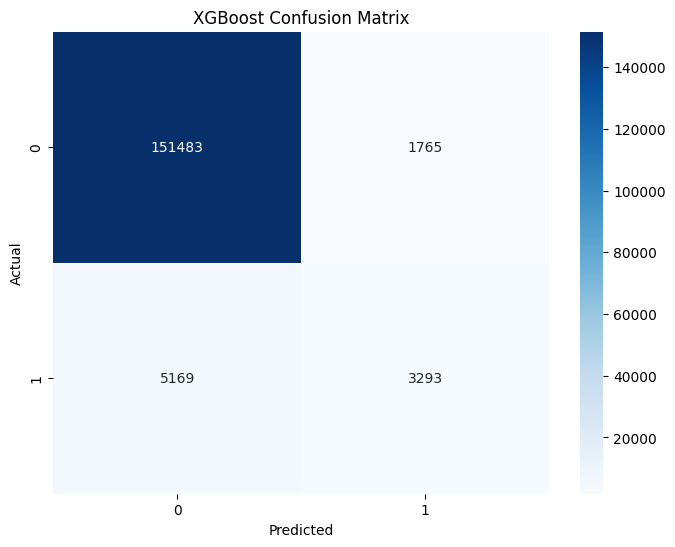

In [11]:
cm = confusion_matrix(y_test, preds_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Feature Importance

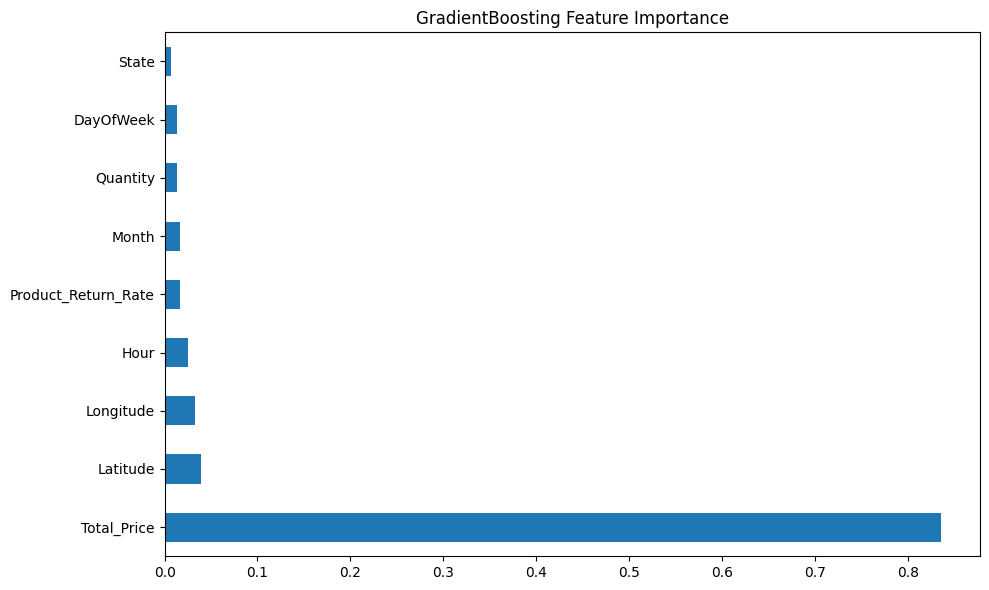

In [12]:
plt.figure(figsize=(10, 6))
if HAS_XGB:
    xgb.plot_importance(model, max_num_features=10)
    plt.title('XGBoost Feature Importance')
else:
    feat_imp = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
    feat_imp.head(10).plot(kind='barh')
    plt.title('GradientBoosting Feature Importance')

plt.tight_layout()
plt.show()